In [1]:
# ============================================================
# F1M1 — Módulo 1: EDA Leonali
# Notebook 02 — EDA Univariado
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_parquet('../data/processed/Dataset1_anonimizado.parquet')

# Variables a analizar
numericas   = ['Costo_Entrega', 'Costo_Produccion', 'Costo_Venta',
               'Piezas_Entregadas', 'Piezas_Ordenadas', 'Piezas_Producidas']
categoricas = ['Categoria1', 'Categoria2', 'marca', 'Canal1', 'Canal2']

print(f"✓ Dataset cargado: {df.shape}")

✓ Dataset cargado: (581306, 15)


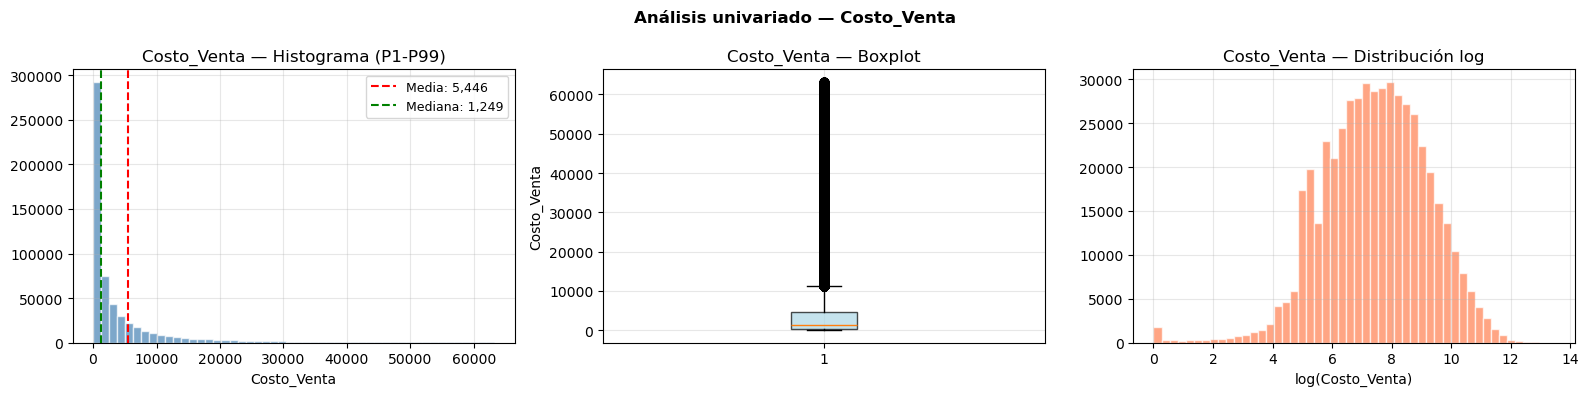


  Costo_Venta
  Media:                5,445.72
  Mediana:              1,249.43
  Std:                 13,333.39
  CV:                     244.8%
  Q1:                     248.76
  Q3:                   4,855.20
  IQR:                  4,606.44
  Lím. inferior:       -6,660.90
  Lím. superior:       11,764.86
  Outliers:               67,807 (11.7%)
  Negativos:                   0

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=245% → dispersión muy alta


In [2]:
# ============================================================
# ANÁLISIS UNIVARIADO — VARIABLES NUMÉRICAS
# ============================================================

def analisis_univariado(df, columna):
    """Análisis completo de una variable numérica"""
    serie = df[columna].dropna()
    
    # Estadísticos
    media    = serie.mean()
    mediana  = serie.median()
    std      = serie.std()
    q1       = serie.quantile(0.25)
    q3       = serie.quantile(0.75)
    iqr      = q3 - q1
    lim_inf  = q1 - 1.5 * iqr
    lim_sup  = q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    cv       = std / media * 100 if media != 0 else 0
    
    # Gráficos
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Histograma (sin outliers extremos para mejor visualización)
    serie_viz = serie[(serie >= serie.quantile(0.01)) & 
                      (serie <= serie.quantile(0.99))]
    axes[0].hist(serie_viz, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].axvline(media,   color='red',   linestyle='--', linewidth=1.5, label=f'Media: {media:,.0f}')
    axes[0].axvline(mediana, color='green', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:,.0f}')
    axes[0].set_title(f'{columna} — Histograma (P1-P99)')
    axes[0].set_xlabel(columna)
    axes[0].legend(fontsize=9)
    
    # Boxplot
    axes[1].boxplot(serie_viz, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[1].set_title(f'{columna} — Boxplot')
    axes[1].set_ylabel(columna)
    
    # Distribución log (si hay valores positivos)
    serie_pos = serie[serie > 0]
    if len(serie_pos) > 0:
        axes[2].hist(np.log1p(serie_pos), bins=50, 
                     color='coral', alpha=0.7, edgecolor='white')
        axes[2].set_title(f'{columna} — Distribución log')
        axes[2].set_xlabel(f'log({columna})')
    
    plt.suptitle(f'Análisis univariado — {columna}', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/02_univariado_{columna}.png', 
                dpi=120, bbox_inches='tight')
    plt.show()
    
    # Resumen
    print(f"\n{'='*50}")
    print(f"  {columna}")
    print(f"{'='*50}")
    print(f"  Media:         {media:>15,.2f}")
    print(f"  Mediana:       {mediana:>15,.2f}")
    print(f"  Std:           {std:>15,.2f}")
    print(f"  CV:            {cv:>14.1f}%")
    print(f"  Q1:            {q1:>15,.2f}")
    print(f"  Q3:            {q3:>15,.2f}")
    print(f"  IQR:           {iqr:>15,.2f}")
    print(f"  Lím. inferior: {lim_inf:>15,.2f}")
    print(f"  Lím. superior: {lim_sup:>15,.2f}")
    print(f"  Outliers:      {len(outliers):>15,} ({len(outliers)/len(serie)*100:.1f}%)")
    print(f"  Negativos:     {(serie < 0).sum():>15,}")
    
    # Señales de negocio
    if media > mediana * 1.5:
        print(f"\n  ⚠️  Media >> Mediana → cola derecha pronunciada")
    if cv > 100:
        print(f"  ⚠️  CV={cv:.0f}% → dispersión muy alta")
    if (serie < 0).sum() > 0:
        print(f"  ⚠️  Hay valores negativos → revisar devoluciones/ajustes")
    
    return {'columna': columna, 'media': media, 'mediana': mediana,
            'cv': cv, 'outliers_pct': len(outliers)/len(serie)*100,
            'negativos': (serie < 0).sum()}

# Correr para la primera variable
resultado = analisis_univariado(df, 'Costo_Venta')

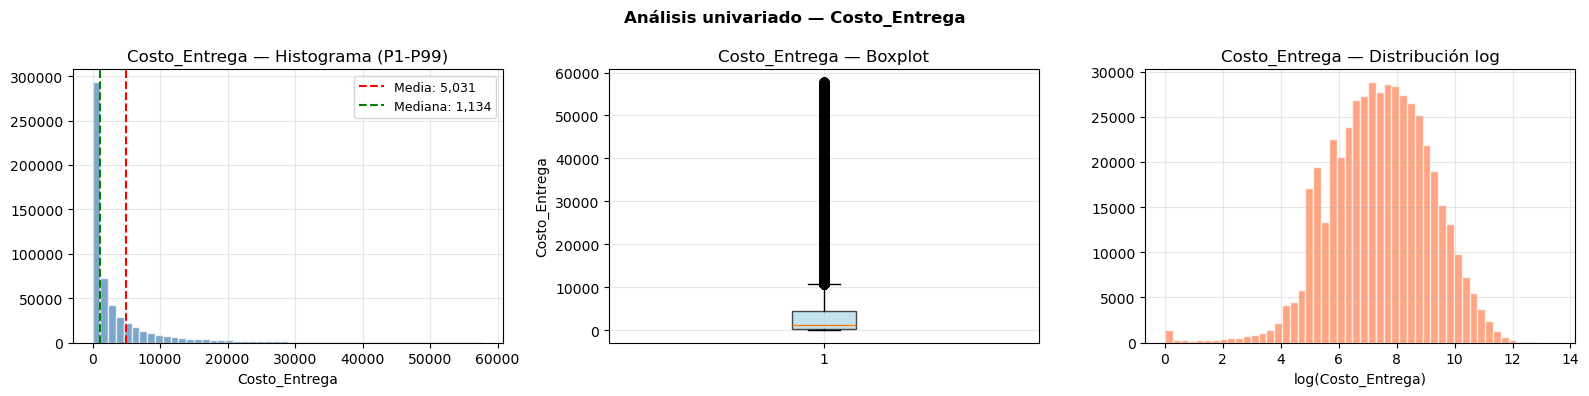


  Costo_Entrega
  Media:                5,031.31
  Mediana:              1,133.95
  Std:                 12,197.21
  CV:                     242.4%
  Q1:                     187.60
  Q3:                   4,552.93
  IQR:                  4,365.33
  Lím. inferior:       -6,360.40
  Lím. superior:       11,100.93
  Outliers:               67,572 (11.6%)
  Negativos:                   3

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=242% → dispersión muy alta
  ⚠️  Hay valores negativos → revisar devoluciones/ajustes



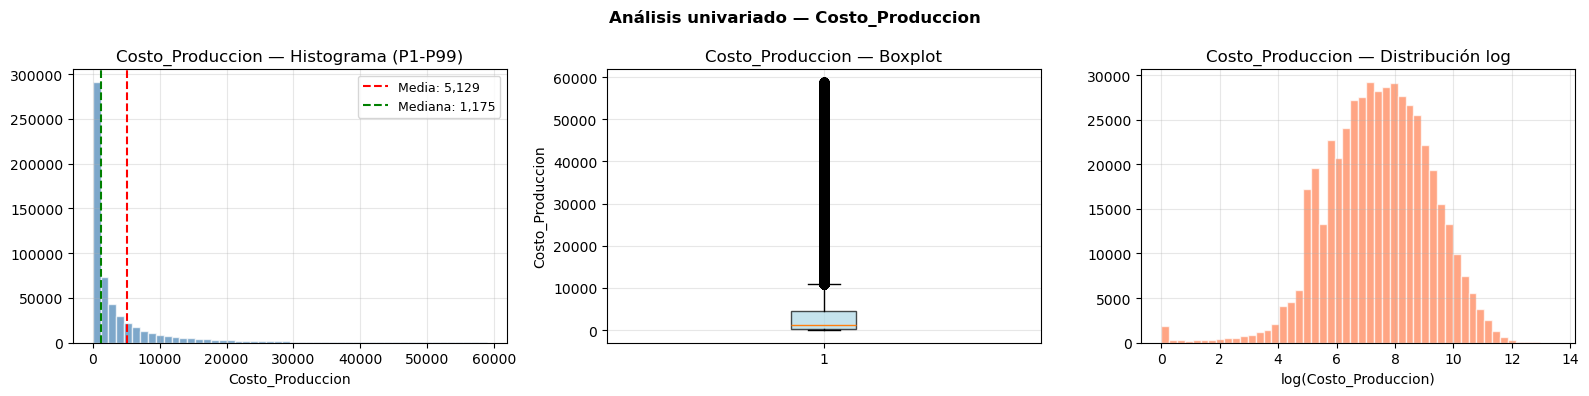


  Costo_Produccion
  Media:                5,128.73
  Mediana:              1,175.26
  Std:                 12,325.67
  CV:                     240.3%
  Q1:                     203.43
  Q3:                   4,665.00
  IQR:                  4,461.57
  Lím. inferior:       -6,488.94
  Lím. superior:       11,357.36
  Outliers:               67,244 (11.6%)
  Negativos:                   6

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=240% → dispersión muy alta
  ⚠️  Hay valores negativos → revisar devoluciones/ajustes



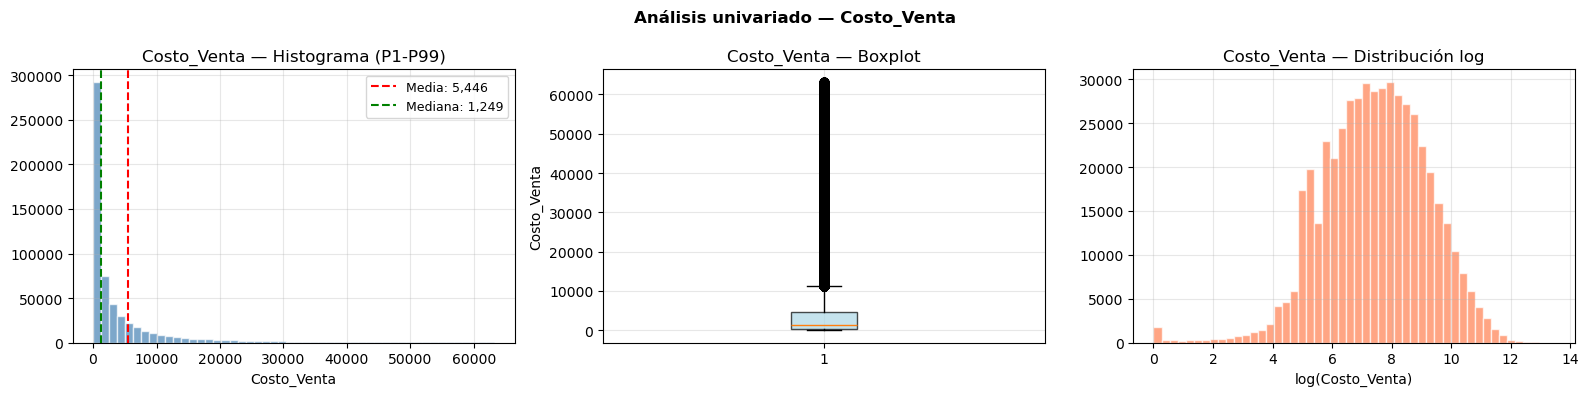


  Costo_Venta
  Media:                5,445.72
  Mediana:              1,249.43
  Std:                 13,333.39
  CV:                     244.8%
  Q1:                     248.76
  Q3:                   4,855.20
  IQR:                  4,606.44
  Lím. inferior:       -6,660.90
  Lím. superior:       11,764.86
  Outliers:               67,807 (11.7%)
  Negativos:                   0

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=245% → dispersión muy alta



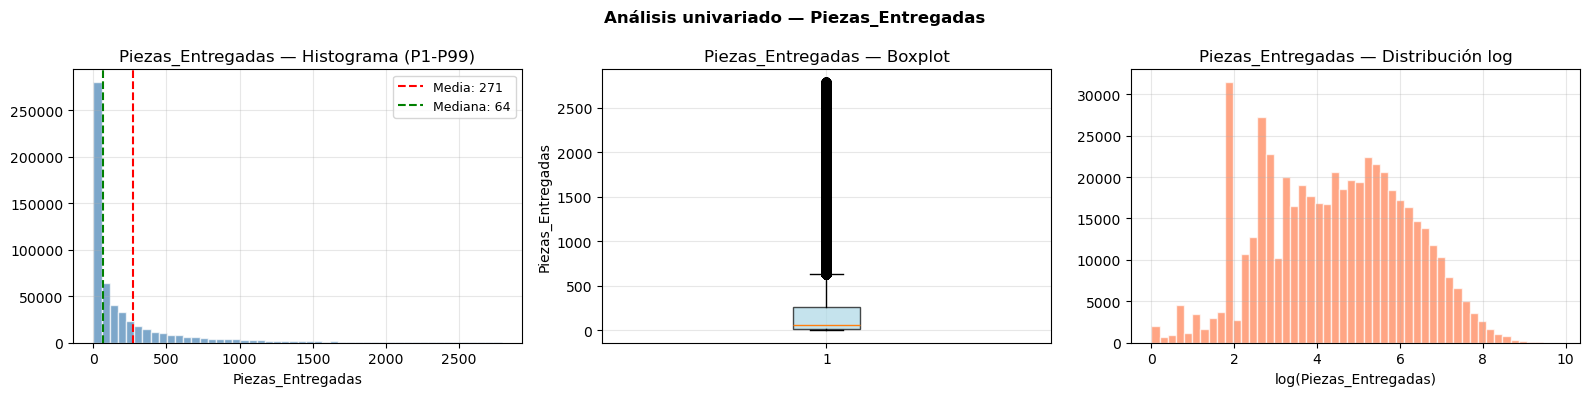


  Piezas_Entregadas
  Media:                  270.59
  Mediana:                 64.00
  Std:                    572.28
  CV:                     211.5%
  Q1:                      12.00
  Q3:                     270.00
  IQR:                    258.00
  Lím. inferior:         -375.00
  Lím. superior:          657.00
  Outliers:               66,623 (11.5%)
  Negativos:                   1

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=211% → dispersión muy alta
  ⚠️  Hay valores negativos → revisar devoluciones/ajustes



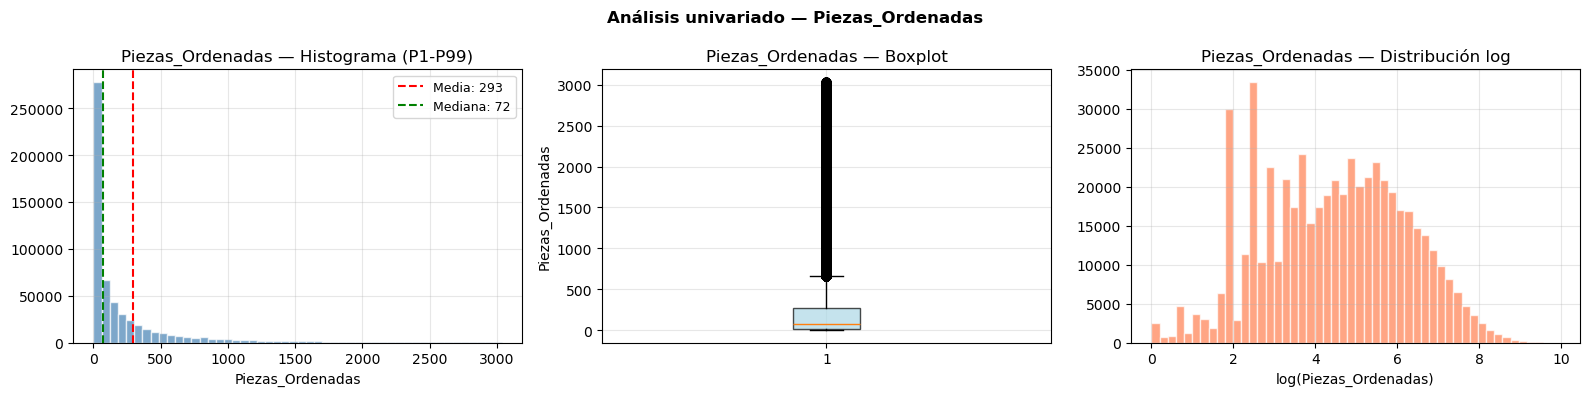


  Piezas_Ordenadas
  Media:                  292.66
  Mediana:                 72.00
  Std:                    632.55
  CV:                     216.1%
  Q1:                      13.00
  Q3:                     286.00
  IQR:                    273.00
  Lím. inferior:         -396.50
  Lím. superior:          695.50
  Outliers:               66,967 (11.5%)
  Negativos:                   0

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=216% → dispersión muy alta



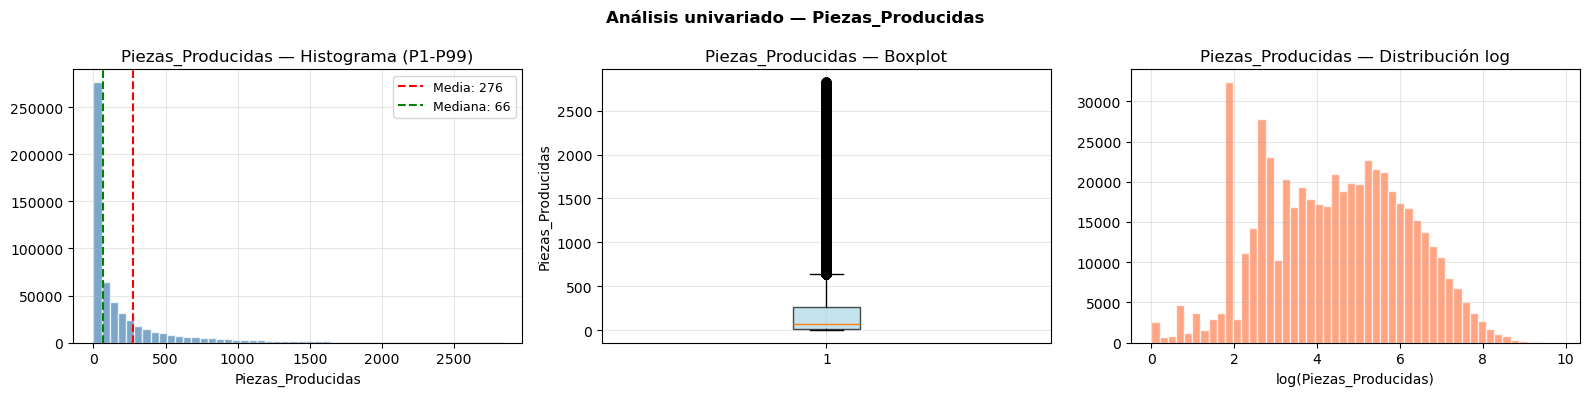


  Piezas_Producidas
  Media:                  275.93
  Mediana:                 66.00
  Std:                    578.73
  CV:                     209.7%
  Q1:                      12.00
  Q3:                     273.00
  IQR:                    261.00
  Lím. inferior:         -379.50
  Lím. superior:          664.50
  Outliers:               67,013 (11.5%)
  Negativos:                   3

  ⚠️  Media >> Mediana → cola derecha pronunciada
  ⚠️  CV=210% → dispersión muy alta
  ⚠️  Hay valores negativos → revisar devoluciones/ajustes



In [3]:
# Correr para todas las variables numéricas
resultados = []
for col in numericas:
    r = analisis_univariado(df, col)
    resultados.append(r)
    print()
    

In [4]:
# ============================================================
# PASO — ¿Son los mismos outliers en todas las variables?
# ============================================================

# Identificar outliers en cada variable
outlier_masks = {}
for col in numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outlier_masks[col] = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)

# ¿Cuántos registros son outliers en TODAS las variables simultáneamente?
todos_outliers = pd.DataFrame(outlier_masks)
outliers_en_n = todos_outliers.sum(axis=1)

print("=== SOLAPAMIENTO DE OUTLIERS ===")
print(f"Registros outlier en 0 variables: {(outliers_en_n == 0).sum():,}")
print(f"Registros outlier en 1 variable:  {(outliers_en_n == 1).sum():,}")
print(f"Registros outlier en 2 variables: {(outliers_en_n == 2).sum():,}")
print(f"Registros outlier en 3 variables: {(outliers_en_n == 3).sum():,}")
print(f"Registros outlier en 4 variables: {(outliers_en_n == 4).sum():,}")
print(f"Registros outlier en 5 variables: {(outliers_en_n == 5).sum():,}")
print(f"Registros outlier en 6 variables: {(outliers_en_n == 6).sum():,}")
print(f"\nTotal registros con al menos 1 outlier: {(outliers_en_n >= 1).sum():,}")

=== SOLAPAMIENTO DE OUTLIERS ===
Registros outlier en 0 variables: 498,109
Registros outlier en 1 variable:  2,145
Registros outlier en 2 variables: 5,129
Registros outlier en 3 variables: 19,157
Registros outlier en 4 variables: 2,461
Registros outlier en 5 variables: 2,322
Registros outlier en 6 variables: 51,983

Total registros con al menos 1 outlier: 83,197



Categoria1 — 11 únicos
Categoria1
Botana       209214
Hojas        102335
Ensalada      90369
Espinaca      67017
Abarrotes     64765

Categoria2 — 9 únicos
Categoria2
Botana       202007
Hojas        103510
Ensalada      90369
Espinaca      67017
Abarrotes     64765

marca — 6 únicos
marca
Vegetalistos     514241
Sin Marca         37162
MarketSide        19543
Green Balance      4948
Leonali            3377

Canal1 — 7 únicos
Canal1
Autoservicio       473724
Club de Precios     38446
Otros               37452
Food Service        17869
Conveniencia        12918

Canal2 — 11 únicos
Canal2
Walmart      170899
Soriana      110179
Otros         81062
Comercial     75085
Chedraui      52945


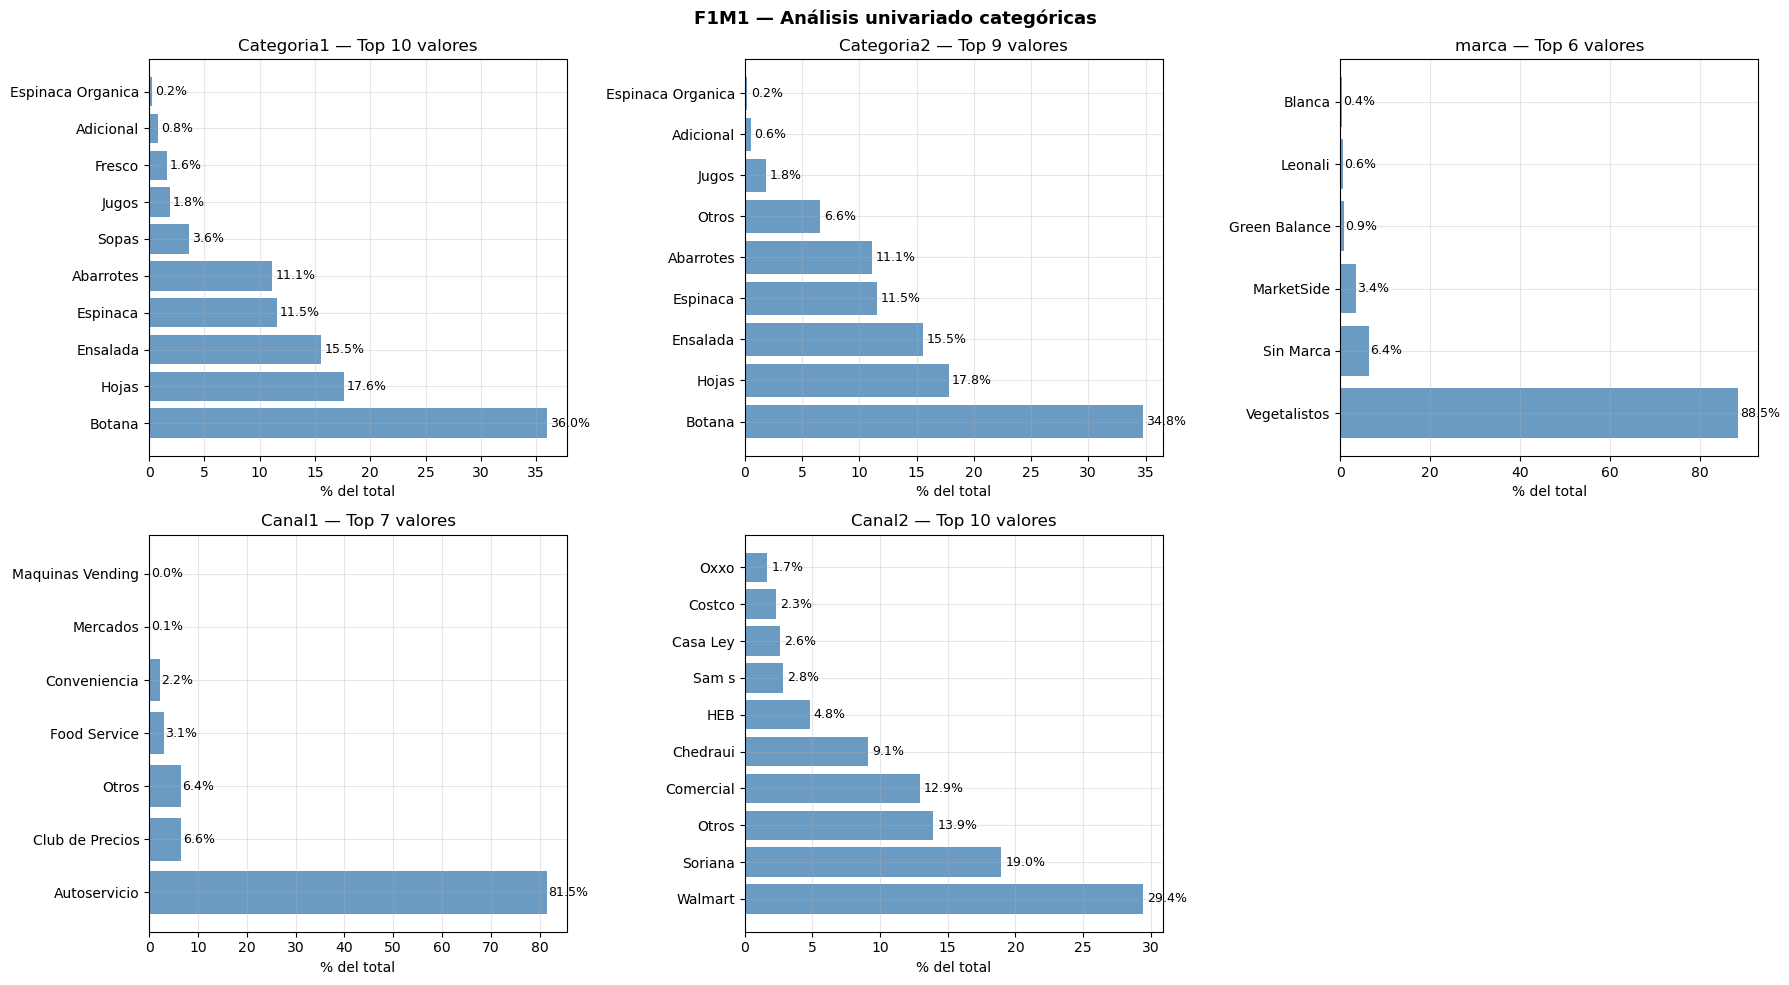

In [8]:
# ============================================================
# ANÁLISIS UNIVARIADO — VARIABLES CATEGÓRICAS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    vc = df[col].value_counts()
    pct = vc / len(df) * 100
    
    bars = axes[i].barh(vc.index[:10], pct.values[:10], 
                         color='steelblue', alpha=0.8)
    axes[i].set_title(f'{col} — Top {min(10,len(vc))} valores')
    axes[i].set_xlabel('% del total')
    
    # Etiquetas
    for bar, p in zip(bars, pct.values[:10]):
        axes[i].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{p:.1f}%', va='center', fontsize=9)
    
    print(f"\n{col} — {df[col].nunique()} únicos")
    print(vc.head(5).to_string())

# Apagar el último subplot si sobra
if len(categoricas) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('F1M1 — Análisis univariado categóricas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_univariado_categoricas.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# RESUMEN — HALLAZGOS EDA UNIVARIADO
# ============================================================

print("=" * 60)
print("HALLAZGOS EDA UNIVARIADO — LEONALI")
print("=" * 60)

print("""
VARIABLES NUMÉRICAS — PATRÓN COMÚN:
  • Todas tienen distribución log-normal (cola derecha pronunciada)
  • CV entre 210% y 245% → dispersión extrema en todas
  • Media >> Mediana en todas → outliers hacia arriba
  • ~11.5% de outliers por variable (IQR method)
  • Transformación log convierte todas a distribución normal

OUTLIERS — SOLAPAMIENTO:
  • 51,983 registros (8.9%) son outliers en las 6 variables simultáneamente
  • Son los pedidos grandes — cuando explota uno, explotan todos
  • Hipótesis: pedidos de temporada, efecto bullwhip, período COVID
  • NO eliminar — etiquetar para tratamiento diferenciado en forecasting

VARIABLES CATEGÓRICAS:
  • Marca: Vegetalistos domina con 88.5% — casi monoproveedor
  • Canal1: Autoservicio = 81.5% — negocio concentrado en retail moderno
  • Canal2: Walmart (29.4%) > Soriana (19%) > Otros (13.9%)
  • Categoría: Botana lidera en volumen (36%) pero Espinaca en valor
  • Categoria1 y Categoria2 casi idénticas → posiblemente redundantes

ALERTAS PARA MÓDULOS FUTUROS:
  • Normalizar con Z-score antes de clustering (no Min-Max por outliers)
  • Tratar período COVID (2020-2022) como atípico en forecasting
  • Costo_Venta ≈ Costo_Produccion → usar solo una en modelos ML
  • Piezas_Ordenadas > Piezas_Entregadas en algunos registros → fill rate
""")

print("PRÓXIMOS PASOS (S5.3):")
print("  • EDA bivariado — relaciones entre variables")
print("  • Análisis temporal — estacionalidad y tendencias")
print("  • Top clientes y productos por valor")

HALLAZGOS EDA UNIVARIADO — LEONALI

VARIABLES NUMÉRICAS — PATRÓN COMÚN:
  • Todas tienen distribución log-normal (cola derecha pronunciada)
  • CV entre 210% y 245% → dispersión extrema en todas
  • Media >> Mediana en todas → outliers hacia arriba
  • ~11.5% de outliers por variable (IQR method)
  • Transformación log convierte todas a distribución normal

OUTLIERS — SOLAPAMIENTO:
  • 51,983 registros (8.9%) son outliers en las 6 variables simultáneamente
  • Son los pedidos grandes — cuando explota uno, explotan todos
  • Hipótesis: pedidos de temporada, efecto bullwhip, período COVID
  • NO eliminar — etiquetar para tratamiento diferenciado en forecasting

VARIABLES CATEGÓRICAS:
  • Marca: Vegetalistos domina con 88.5% — casi monoproveedor
  • Canal1: Autoservicio = 81.5% — negocio concentrado en retail moderno
  • Canal2: Walmart (29.4%) > Soriana (19%) > Otros (13.9%)
  • Categoría: Botana lidera en volumen (36%) pero Espinaca en valor
  • Categoria1 y Categoria2 casi idénticas → 